In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
print(housing.data.shape, housing.target.shape)

(20640, 8) (20640,)


In [5]:
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


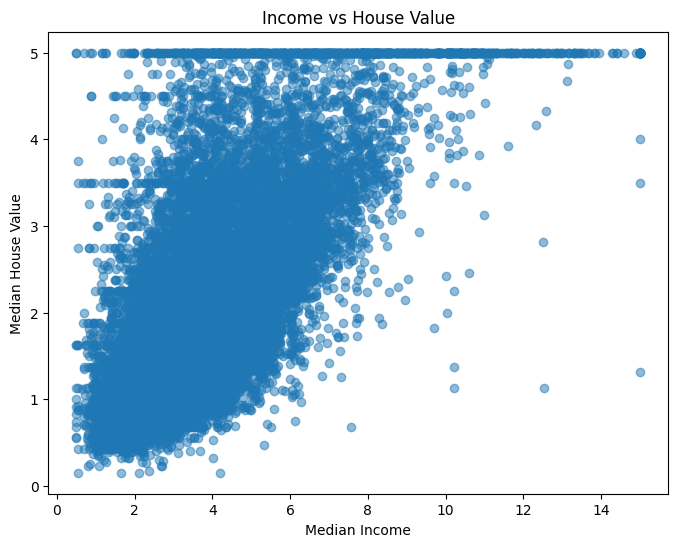

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.5)
plt.title('Income vs House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

# 説明変数（所得のみを選択）と目的変数
X = df[['MedInc']]  # 単回帰なので1列のみ。[[ ]]でDataFrame形式にするのがコツです
y = df['MedHouseVal']

# 学習用80%、テスト用20%に分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
from sklearn.linear_model import LinearRegression

# モデルのインスタンス作成
model = LinearRegression()

# 学習（所得と価格の法則を見つける）
model.fit(X_train, y_train)

# 傾きと切片の表示
print(f"回帰係数（傾き）: {model.coef_[0]:.4f}")
print(f"切片: {model.intercept_:.4f}")

回帰係数（傾き）: 0.4193
切片: 0.4446


In [9]:
# テストデータで予測
y_pred = model.predict(X_test)

# 決定係数（1.0に近いほど高精度）
score = model.score(X_test, y_test)
print(f"決定係数 (R^2): {score:.4f}")

決定係数 (R^2): 0.4589


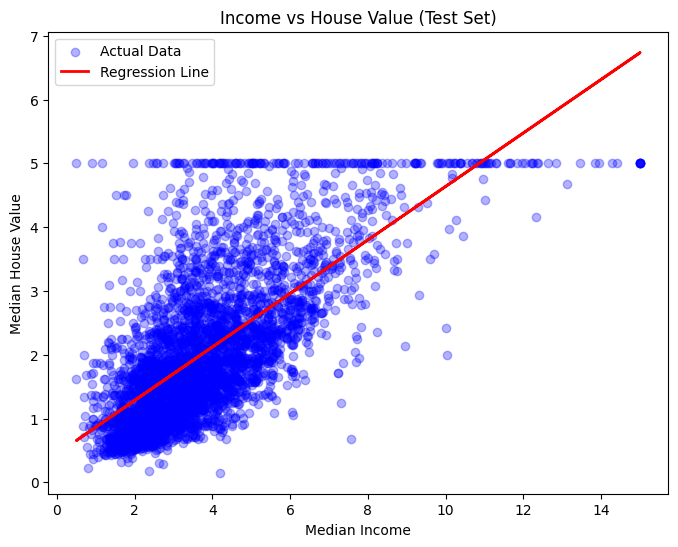

In [10]:
plt.figure(figsize=(8, 6))

# 1. 元のデータ（テストデータ）を散布図として描画
plt.scatter(X_test, y_test, color='blue', alpha=0.3, label='Actual Data')

# 2. 回帰直線を赤い線で描画
# X軸はテストデータの所得、Y軸は予測値(y_pred)を指定します
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')

plt.title('Income vs House Value (Test Set)')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.legend()
plt.show()

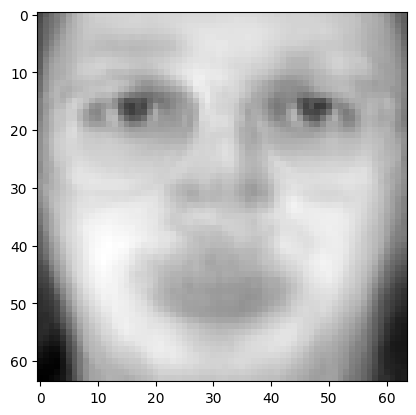

In [11]:
from sklearn import datasets 
faces, _ =datasets.fetch_olivetti_faces(return_X_y=True)
# faces is a ndarray of shape (400,4096)
mean = np.mean(faces,axis=0)
faces=faces-mean
Cov=np.dot(faces,faces.T)/400
eigval, eigvec_v = np.linalg.eig(Cov)

eigvec_u=np.dot(faces.T, eigvec_v)

for i in range(400):
    eigvec_u[:,i]/=np.linalg.norm(eigvec_u[:,i])

a=np.dot(faces[000],eigvec_u[:,:10])
revface=np.dot(a,eigvec_u[:,:10].T)

##for Jupyter users
revface=revface+mean
plt.imshow(revface.reshape([64,64]), cmap="gray")